In [30]:
import librosa
import librosa.onset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

## Configurazione

In [ ]:
AUDIO_FILE = "il laminatore.mp3"

SENSITIVITY = 0.8

OUTPUT_CSV = "transients.csv"

## Caricamento audio e rilevamento transienti

In [44]:
def detect_transients(audio_path: str, sensitivity: float = 0.5):
    y, sr = librosa.load(audio_path, sr=None, mono=True)
    duration = librosa.get_duration(y=y, sr=sr)

    hop_length = 512
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop_length)

    onset_env_norm = onset_env / (onset_env.max() + 1e-10)

    threshold = 1.0 - np.clip(sensitivity, 0.0, 1.0)

    delta = max(0.01, 0.07 * (1.0 - sensitivity))
    wait = max(1, int(0.05 * sr / hop_length))

    onset_frames = librosa.onset.onset_detect(
        onset_envelope=onset_env,
        sr=sr,
        hop_length=hop_length,
        delta=delta,
        wait=wait,
        units="frames",
    )

    peak_values = onset_env_norm[onset_frames]
    mask = peak_values >= threshold
    onset_frames = onset_frames[mask]

    onset_times = librosa.frames_to_time(onset_frames, sr=sr, hop_length=hop_length)
    onset_strengths = onset_env_norm[onset_frames]

    return y, sr, duration, onset_env, onset_times, onset_strengths, hop_length


y, sr, duration, onset_env, onset_times, onset_strengths, hop_length = detect_transients(
    AUDIO_FILE, SENSITIVITY
)

print(f"File: {AUDIO_FILE}")
print(f"Sample rate: {sr} Hz")
print(f"Durata: {duration:.2f} s")
print(f"Transienti rilevati: {len(onset_times)}")

File: il laminatore.mp3
Sample rate: 44100 Hz
Durata: 13.39 s
Transienti rilevati: 61


## Grafico

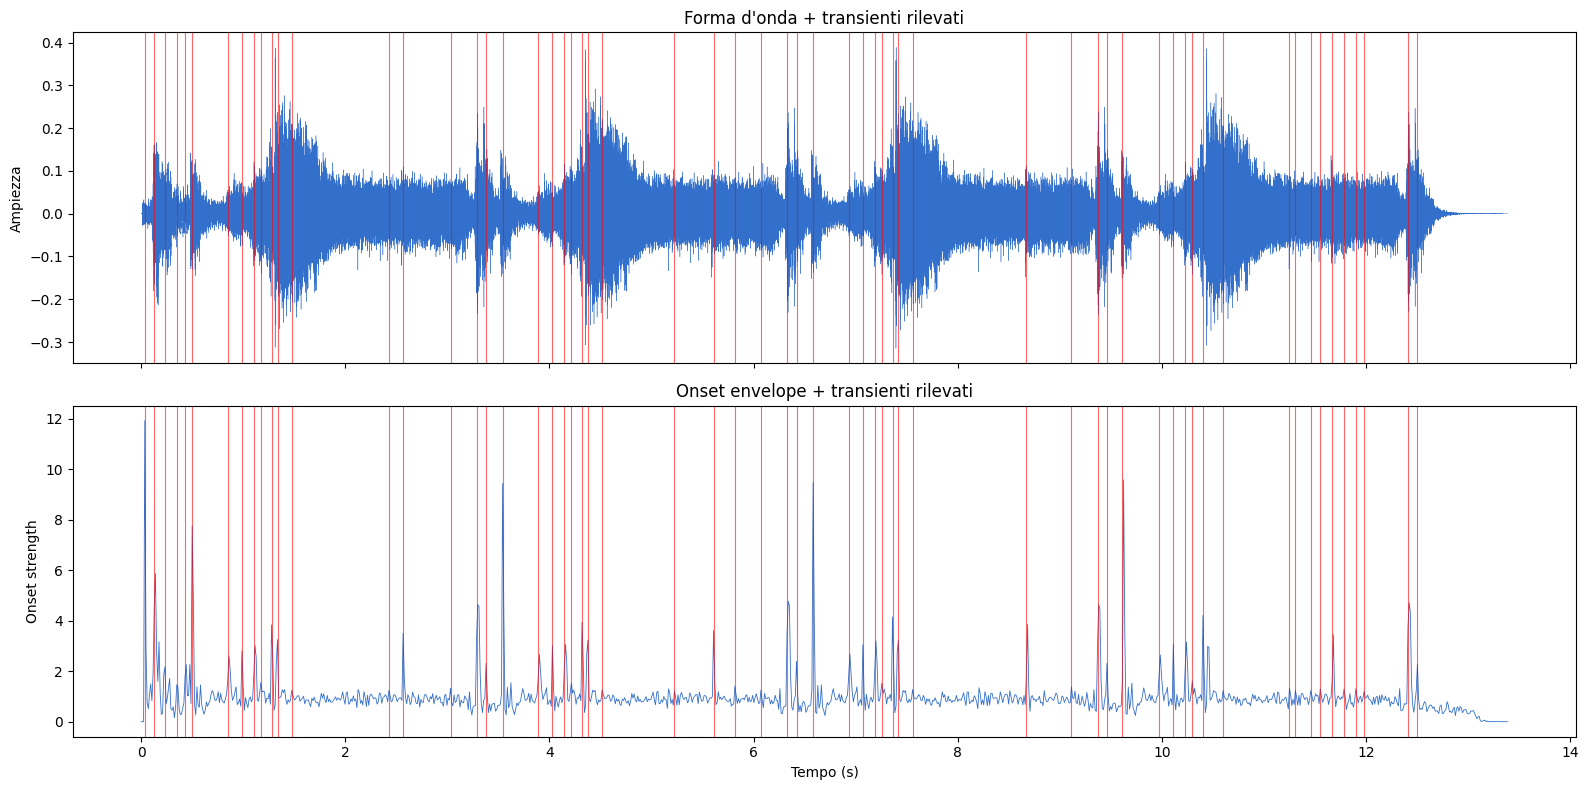

In [45]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

time_axis = np.linspace(0, duration, num=len(y))
axes[0].plot(time_axis, y, linewidth=0.3, color="#3370cc")
for t in onset_times:
    axes[0].axvline(x=t, color="red", alpha=0.6, linewidth=0.8)
axes[0].set_ylabel("Ampiezza")
axes[0].set_title("Forma d'onda + transienti rilevati")

env_time = librosa.frames_to_time(np.arange(len(onset_env)), sr=sr, hop_length=hop_length)
axes[1].plot(env_time, onset_env, linewidth=0.6, color="#3370cc")
for t in onset_times:
    axes[1].axvline(x=t, color="red", alpha=0.6, linewidth=0.8)
axes[1].set_ylabel("Onset strength")
axes[1].set_xlabel("Tempo (s)")
axes[1].set_title("Onset envelope + transienti rilevati")

plt.tight_layout()
plt.show()

## Esportazione CSV

In [46]:
df = pd.DataFrame({
    "transient_index": np.arange(1, len(onset_times) + 1),
    "timestamp_s": np.round(onset_times, 6),
    "strength": onset_strengths,
    "strength_rounded": np.round(onset_strengths, 2),
})

df.to_csv(OUTPUT_CSV, index=False)
print(f"CSV salvato in: {os.path.abspath(OUTPUT_CSV)}")
df.head(20)

CSV salvato in: /Users/giovanniabbatepaolo/Documents/GitHub/aba-perugia/tesi-clelia-calcatelli/research/transient_detector_py/transients.csv


,transient_index,timestamp_s,strength,strength_rounded
0,1,0.034830,1.000000,1.00
1,2,0.127710,0.381631,0.38
2,3,0.232200,0.182215,0.18
3,4,0.348299,0.122905,0.12
4,5,0.429569,0.149399,0.15
5,6,0.499229,0.650372,0.65
6,7,0.847528,0.135131,0.14
7,8,0.986848,0.235344,0.24
8,9,1.102948,0.151340,0.15
9,10,1.172608,0.130706,0.13
